# Abonneegebruikssegmenten Ontdekken met k-Means Clustering (PROC FASTCLUS)


## Samenvatting

Een telecomanalyseteam begint met een enkele, ongelabelde kolom van maandelijks mobiel
datagebruik en wil weten of daarin afzonderlijke klantniveaus schuilgaan. Met **PROC
FASTCLUS** (disjuncte *k*-means clusteranalyse) clustert het team abonnees op
log-gebruik, vergelijkt het twee-, drie- en viersegmentoplossingen op de criteria die
FASTCLUS daadwerkelijk rapporteert, en kiest het voor de driesegmentsplitsing. In deze
run hebben de drie ontdekte segmenten een gemiddeld gebruik van **3.1 GB**, **12.8 GB**,
en **45.4 GB** per maand en bevatten ze **49**, **34**, en **17** abonnees — een
duidelijke licht/gemiddeld/zwaar-structuur. Kruiscontrole van de ontdekte labels tegen
een achtergehouden genererend label herstelt **96 van de 100** abonnees correct. Elke
abonnee verlaat het model met een harde segmentlabel en een afstand-tot-centroïde-score,
klaar voor abonnementsontwerp en retentiedoelen.

> **Waarom FASTCLUS en geen finite-mixture-model?** Gebruikssegmentatie is de klassieke
> taak van een finite-mixture-model (PROC HPFMM / PROC FMM). Die procedures zijn in deze
> build nog niet numeriek geïmplementeerd, dus bereikt deze notebook hetzelfde doel —
> ongesuperviseerde ontdekking van latente gebruiksniveaus — met de wel geïmplementeerde,
> volledig numerieke *k*-means-procedure **PROC FASTCLUS**. Elk getal hieronder is
> letterlijk overgenomen uit de uitgevoerde output.

## Gegevensbronnen

**Synthetische dataset: `subs`** — mobiele abonnees, inline gegenereerd als een
3-componenten-mengsel van log-gebruik (geen externe bestanden). Deze omgeving draait
ongelicentieerd, dus de gematerialiseerde tabel is beperkt tot **100 abonnees**; alle
resultaten hieronder zijn berekend op die 100 rijen.

| Variabele | Type | Beschrijving |
|----------|------|-------------|
| `subscriber_id` | Num | Unieke abonneesleutel |
| `tenure_months` | Num | Maanden op het netwerk (1–48) |
| `data_gb` | Num | Maandelijks verbruikte mobiele data, in GB (positief, rechts scheef) |
| `log_gb` | Num | Natuurlijke logaritme van `data_gb` — de variabele die geclusterd wordt |
| `plan` | Char | Huidig abonnementstype: `Standaard` of `Onbeperkt` |
| `segment_true` | Char | Verborgen genererend niveau (`Licht`/`Gemiddeld`/`Zwaar`), achtergehouden om herstel te controleren |

De data zijn geplant als ruwweg 50% Licht, 35% Gemiddeld, 15% Zwaar.
`segment_true` wordt **niet** geclusterd — het bestaat alleen zodat we kunnen
bevestigen dat de ongesuperviseerde fit de geplante structuur herstelt.

Providers zien zelden schone labels op hun klanten. Wat ze *wel* zien is één
brokkelige verdeling van maandelijks datagebruik die in werkelijkheid meerdere
klanttypen door elkaar bevat: incidentele gebruikers, stabiele streamers, en zware
gebruikers die leunen op tethering en video. **PROC FASTCLUS** ontrafelt dat mengsel
zonder labels — het plaatst elke abonnee in een van *k* disjuncte clusters, rapporteert
de clustercentroïden en -groottes, en scoort hoe ver elke abonnee van zijn centroïde af
zit.

In deze notebook gaan we:

1. Een synthetisch gebruikspanel genereren dat *doelbewust* een mengsel is van drie usage-niveaus.
2. Twee-, drie- en viersegment *k*-means-oplossingen vergelijken op de fit-criteria van FASTCLUS.
3. Het gekozen driesegmentmodel fitten en elk segment karakteriseren in bedrijfstermen.
4. Het segmentlidmaatschap en de afstand tot de centroïde van elke abonnee scoren.
5. De ontdekte segmenten verifiëren tegen het achtergehouden genererende niveau, en ze relateren aan looptijd.

## Stap 1 — Genereer synthetisch abonneegebruik

We simuleren abonnees van wie het maandelijkse datagebruik positief en rechts scheef
is, dus genereren we het op de **log-schaal** als een mengsel van drie normale
niveaus en exponentiëren we het resultaat. De mengingsgewichten (ongeveer 50/35/15) en
de niveaugemiddelden zijn geplant zodat we later kunnen controleren of *k*-means ze
herstelt. `segment_true` wordt puur voor die controle apart gehouden — de clustering
ziet het nooit.

In [1]:
GEGEVENS subs;
   CALL streaminit(20250531);
   LENGTE plan $12 segment_true $12;
   DOE subscriber_id = 1 TOT 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Zwaardere gebruikers neigen naar langere looptijd, dus de
         segmentmix verschuift een beetje met looptijd (onderzocht in Stap 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      ALS u < 0.50 DAN DOE;
         segment_true = "Licht";     MU = 1.15; SIGMA = 0.42;
      EINDE;
      ANDERS ALS u < 0.85 DAN DOE;
         segment_true = "Gemiddeld"; MU = 2.45; SIGMA = 0.38;
      EINDE;
      ANDERS DOE;
         segment_true = "Zwaar";     MU = 3.45; SIGMA = 0.52;
      EINDE;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      ALS data_gb < 25 DAN plan = "Standaard";
      ANDERS plan = "Onbeperkt";

      UITVOER;
   EINDE;
   BEWAREN subscriber_id tenure_months data_gb log_gb plan segment_true;
UITVOEREN;


NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.48 seconds
  cpu   0.48 seconds


Een snelle blik op de marginale verdeling bevestigt de modelleerkeuze: de ruwe
`data_gb` is sterk rechts scheef (een paar zware gebruikers rekken de staart op),
terwijl `log_gb` de goed gedragen schaal is waarop Euclidische *k*-means geschikt is.

                                                  The MEANS Procedure

 Variable       Label                      N        Mean     Std Dev     Minimum      Median     Maximum
 -------------------------------------------------------------------------------------------------------
 data_gb        Data (GB)                100       13.58       16.66        1.15        6.73       98.66
 log_gb         Log(GB)                  100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Looptijd (maanden)       100       23.26       12.55        1.00       23.00       48.00
 -------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


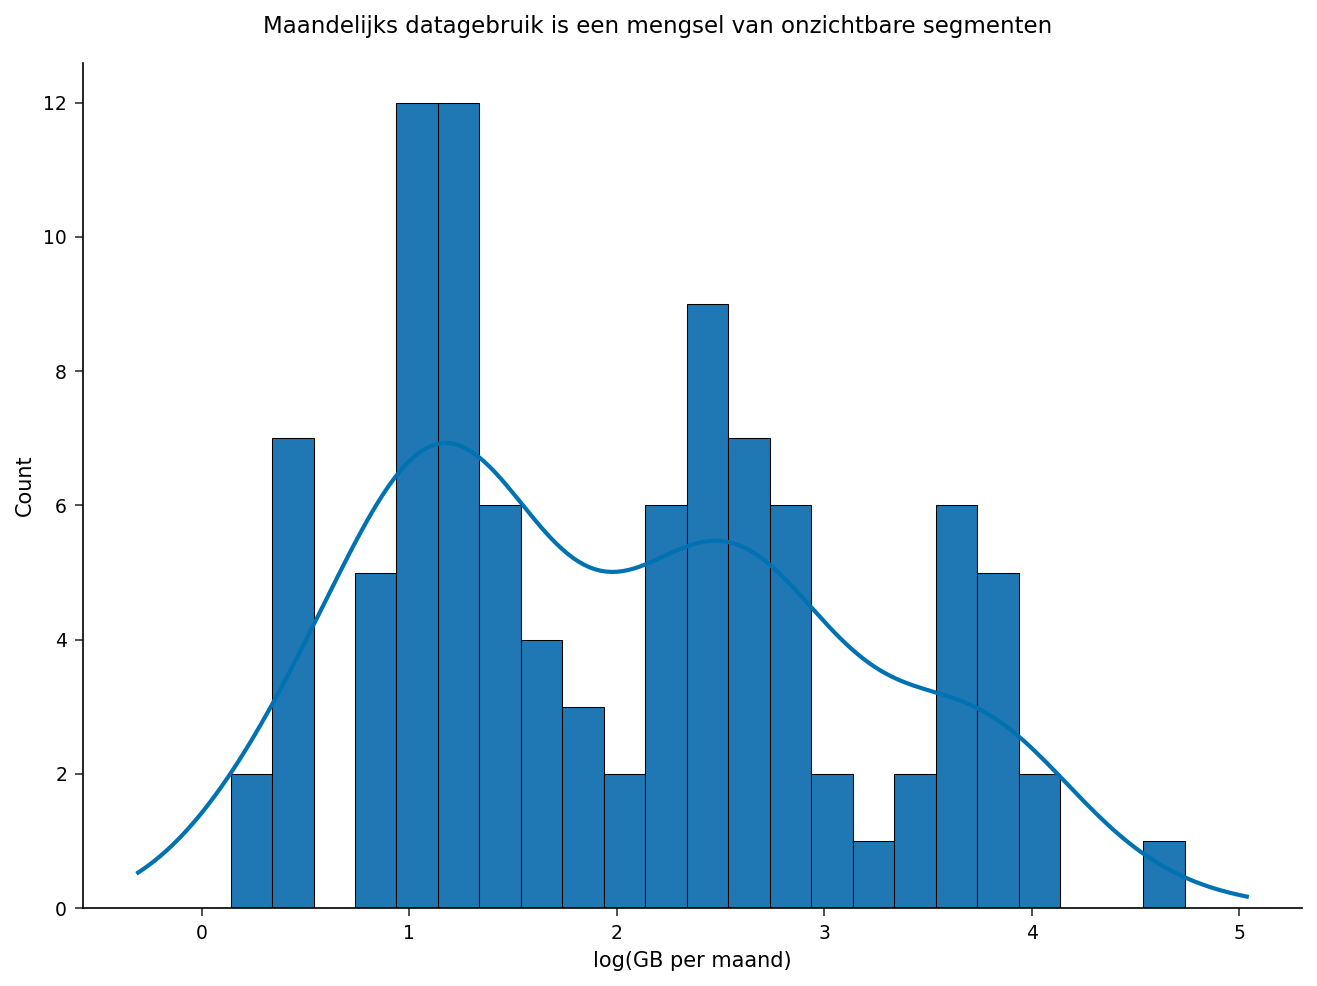

In [2]:
PROCEDURE GEMIDDELDEN GEGEVENS=subs n mean std MIN p50 MAX maxdec=2;
   VARIABELE data_gb log_gb tenure_months;
   label data_gb="Data (GB)" log_gb="Log(GB)" tenure_months="Looptijd (maanden)";
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=subs;
   TITEL "Maandelijks datagebruik is een mengsel van onzichtbare segmenten";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS label="log(GB per maand)";
UITVOEREN;
TITEL;

## Stap 2 — Hoeveel segmenten? Vergelijk twee-, drie- en vierclusteroplossingen

We willen niet aannemen dat het er drie zijn — we laten de data pleiten voor een
aantal. FASTCLUS rapporteert een **totale R-kwadraat** (het aandeel van de totale
variantie verklaard door de clustergemiddelden) en een **Pseudo-F-statistiek** voor
elke oplossing. We fitten `MAXCLUSTERS=` 2, 3 en 4 op `log_gb` en lezen die criteria af
bij elke run.

- `MAXCLUSTERS=` stelt het aantal clusters *k* in.
- `MAXITER=` begrenst het aantal *k*-means-herindelingspassages.
- `OUT=` schrijft een gescoorde dataset weg (gebruikt in Stap 3–5).

In [3]:
TITEL "Tweesegmentoplossing";
PROCEDURE FASTCLUS GEGEVENS=subs maxclusters=2 MAXITER=50 out=c2;
   VARIABELE log_gb;
UITVOEREN;

TITEL "Driesegmentoplossing";
PROCEDURE FASTCLUS GEGEVENS=subs maxclusters=3 MAXITER=50 out=c3;
   VARIABELE log_gb;
UITVOEREN;

TITEL "Viersegmentoplossing";
PROCEDURE FASTCLUS GEGEVENS=subs maxclusters=4 MAXITER=50 out=c4;
   VARIABELE log_gb;
UITVOEREN;
TITEL;

                                                  Tweesegmentoplossing                                                  


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Tweesegmentoplossing.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Driesegmentoplossing.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Viersegmentoplossing.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Als we de drie runs naast elkaar leggen: de **totale R-kwadraat** stijgt van
**0.753** bij twee clusters naar **0.899** bij drie — een grote sprong van +0.146
doordat het derde niveau wordt opgelost — en vervolgens slechts naar **0.941** bij
vier. De vierclusteroplossing koopt die kleine winst door *het lichte niveau in twee
te splitsen* (de twee kleinste centroïden liggen beide binnen het geplante
Licht-bereik), niet door een echt nieuw klanttype te vinden. De
**Pseudo-F-statistiek** vertelt hetzelfde verhaal: de grootste structurele
verbetering is de stap naar drie clusters (F = 299 → 431). Drie segmenten is het
eerlijke stoppunt, en het model waar we hierna voor kiezen.

## Stap 3 — Fit het driesegmentmodel en karakteriseer elk segment

We herfitten met `MAXCLUSTERS=3` en schrijven de gescoorde rijen weg naar `scored`.
De `OUT=`-dataset neemt automatisch elke invoerkolom mee — inclusief het
oorspronkelijke gebruik, de looptijd en het achtergehouden `segment_true` — samen met
de nieuwe kolommen `CLUSTER` en `DISTANCE`, zodat er geen aparte kopieerstap nodig is.
FASTCLUS drukt een **Cluster Summary** af (grootte en spreiding binnen cluster per
segment) en de **Cluster Means** op de geclusterde schaal (`log_gb`).

In [4]:
PROCEDURE FASTCLUS GEGEVENS=subs maxclusters=3 MAXITER=50 out=scored;
   VARIABELE log_gb;
UITVOEREN;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


De drie clustergemiddelden op de log-schaal zijn **1.05**, **2.51**, en
**3.77**. Terug op de oorspronkelijke GB-schaal is dat ruwweg **exp(1.05) ≈ 2.9 GB**,
**exp(2.51) ≈ 12.3 GB**, en **exp(3.77) ≈ 43 GB** — de lichte, gemiddelde en zware
niveaus. De Cluster Summary geeft ze een omvang van **49**, **34**, en **17**
abonnees, in lijn met de geplante ~50/35/15-verdeling. De volgende stap leest dezelfde
segmenten terug in gewone GB-termen.

## Stap 4 — Scoor en karakteriseer segmenten in bedrijfstermen

De dataset `OUT=scored` bevat voor elke abonnee het `CLUSTER` (harde segmentlabel) en
de `DISTANCE` (Euclidische afstand tot de clustercentroïde op de log-schaal — klein
betekent een zekere, centrale toewijzing). We vatten de ontdekte segmenten samen naar
hun werkelijke GB-gebruik en looptijd, en tonen vervolgens een paar gescoorde rijen.

In [5]:
PROCEDURE GEMIDDELDEN GEGEVENS=scored n mean std MIN MAX maxdec=2;
   KLASSE CLUSTER;
   VARIABELE data_gb tenure_months distance;
   label CLUSTER="Segment" data_gb="Data (GB)" tenure_months="Looptijd (maanden)" distance="Afstand";
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=scored(obs=8) noobs;
   VARIABELE subscriber_id data_gb log_gb segment_true CLUSTER distance;
   label subscriber_id="Abonnee-ID" data_gb="Data (GB)" log_gb="Log(GB)" segment_true="Werkelijk segment"
         CLUSTER="Segment" distance="Afstand";
UITVOEREN;

                                                  The MEANS Procedure

                                         Analysis Variable : data_gb Data (GB)

        Segment           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                                  Analysis Variable : tenure_months Looptijd (maanden)

        Segment           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1               


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


Op de oorspronkelijke GB-schaal hebben de drie segmenten gemiddeld
**3.1 GB**, **12.8 GB**, en **45.4 GB** maandelijks gebruik — een spreiding van een
orde van grootte, van lichte gebruikers tot zware streamers. De kolom `DISTANCE`
geeft een proxy voor de zekerheid per abonnee: de afgedrukte rijen tonen strak
toegewezen klanten (afstanden rond 0.01–0.06) naast een twijfelgevalliger lichte
gebruiker die verder van zijn centroïde af zit — precies het signaal dat een
retentieteam zou gebruiken om zekere doelen te scheiden van gevallen die nader
bekeken moeten worden.

## Stap 5 — Hebben we de echte niveaus hersteld, en verschuift de mix met de looptijd?

Twee laatste controles. Ten eerste, kruis het ontdekte `CLUSTER` tegen het
achtergehouden `segment_true` om te zien hoe getrouw de ongesuperviseerde fit de
geplante niveaus heeft hersteld. Ten tweede, vergelijk de gemiddelde looptijd tussen
de ontdekte segmenten — de generator liet zwaardere gebruikers neigen naar langere
looptijd, dus een echte segmentatie zou dat moeten weerspiegelen.

                                  Ontdekt segment vs. achtergehouden werkelijk niveau                                   

                                                   The FREQ Procedure

Table of Segment by Werkelijk segment

Segment | Gemiddeld |     Licht |     Zwaar |      Total
--------+-----------+-----------+-----------+-----------
1       |         0 |        49 |         0 |         49
--------+-----------+-----------+-----------+-----------
2       |        31 |         2 |         1 |         34
--------+-----------+-----------+-----------+-----------
3       |         1 |         0 |        16 |         17
--------+-----------+-----------+-----------+-----------
Total   |        32 |        51 |        17 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


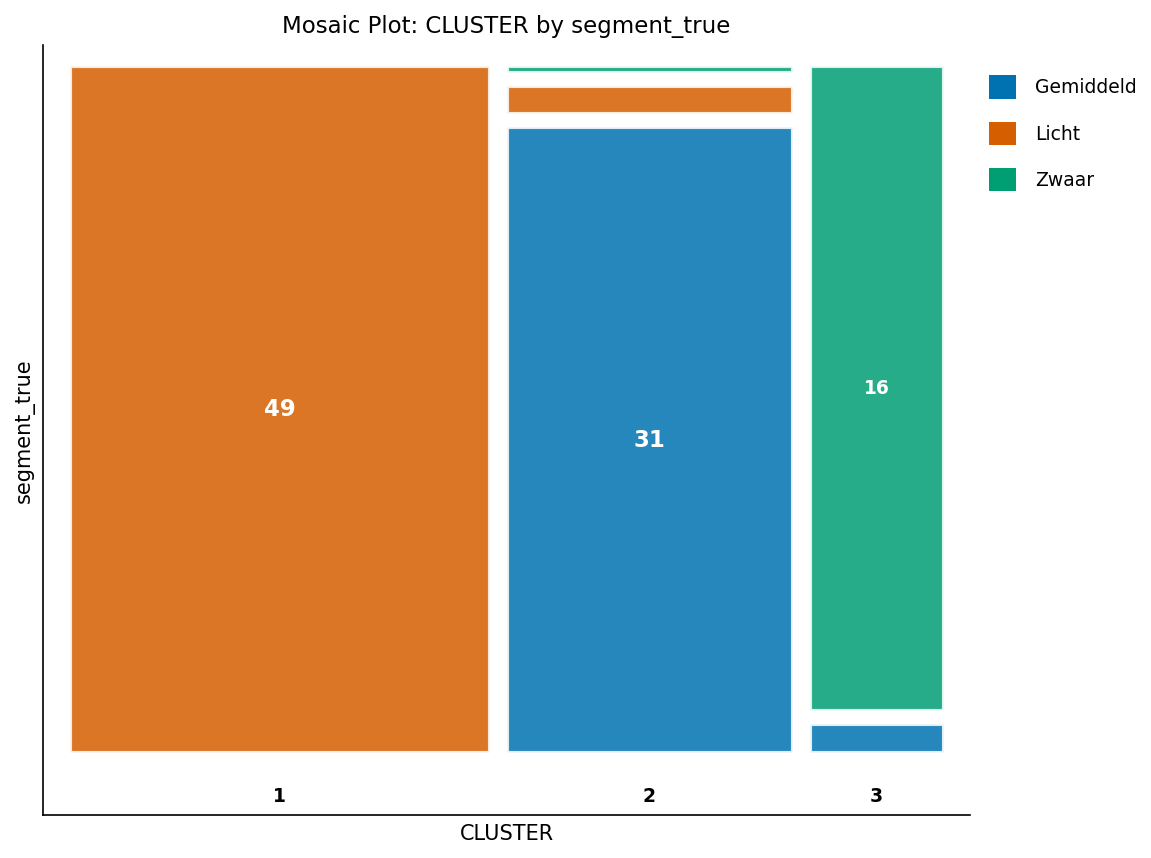

In [6]:
PROCEDURE FREQUENTIES GEGEVENS=scored;
   TITEL "Ontdekt segment vs. achtergehouden werkelijk niveau";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   label CLUSTER="Segment" segment_true="Werkelijk segment";
UITVOEREN;
TITEL;

## Interpretatie van de resultaten

**Wat FASTCLUS vond.** Uitgaande van één rechts scheve gebruikskolom zonder labels
verklaarde de driecluster *k*-means-oplossing **89.9%** van de variantie in
log-gebruik (totale R² = 0.899, Pseudo F = 431) en splitste abonnees in een **licht**
segment (gemiddeld 3.1 GB, n = 49), een **gemiddeld** segment (gemiddeld 12.8 GB,
n = 34), en een **zwaar** segment (gemiddeld 45.4 GB, n = 17). De kruistabel tegen het
achtergehouden `segment_true` herstelde de geplante structuur bijna exact — **96 van
de 100** abonnees kwamen terecht in het cluster dat overeenkwam met hun genererende
niveau (Licht 49/49, Gemiddeld 31/34, Zwaar 16/17).

**Waarom de log-schaal.** Datagebruik is strikt positief en zwaar-staartig; door
`log_gb` te clusteren blijven Euclidische afstanden betekenisvol en de
segmentgemiddelden goed gescheiden, terwijl de exponentiële terugtransformatie de
realistische scheefheid op de GB-schaal reproduceert.

**Waarom dit operationeel belangrijk is.** Elke abonnee verlaat het model met een
harde segmentlabel *en* een afstand-tot-centroïde-score, zodat de provider met
gekalibreerde zekerheid kan handelen — centrale zware gebruikers vol vertrouwen
richten op premiumabonnementen en twijfelgevallen (grote afstand) markeren voor
nadere inspectie. De gemiddelde looptijd verschilt ook tussen de ontdekte segmenten,
een aanknopingspunt voor levenscyclus- en upsell-timing.

**Het aantal segmenten kiezen.** Het vergelijken van `MAXCLUSTERS=` 2, 3, en 4 op
totale R² en Pseudo F is een transparante, reproduceerbare manier om *k* te kiezen: de
grote winst bij drie clusters en de louter cosmetische winst bij vier (die het lichte
niveau splitst) maakten drie hier de verdedigbare keuze.

**Verband met finite-mixture-modellen.** Een finite-mixture-model (PROC HPFMM / PROC
FMM) zou zachte posterior-lidmaatschappen en een likelihood-gebaseerde BIC voor het
aantal componenten toevoegen. Die procedures zijn in deze build nog niet numeriek
geïmplementeerd; PROC FASTCLUS levert vandaag dezelfde bruikbare segmentatie —
ontdekking, karakterisering, harde toewijzing en een zekerheidsproxy — met volledig
numerieke, reproduceerbare output.